#Importing the libraries

In [ ]:
#Import Libraries
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns

#Import the Dataset

In [ ]:
!ls Dataset1.csv
df=pd.read_csv("Dataset1.csv")

# Define only pollutant (continuous) variables
pollutants = ['PAH', '1,3-Butadiene', 'O-Xylene', 'Benzene',
              'Toluene', 'Styrene', 'p-dichloro', 'Chloroform']

# Use those as features
x = df[pollutants].values
df = df.iloc[:, 9:]
# Use AMLoutcome as label
y = df['AMLoutcome']

/content/drive/MyDrive/DanielaGalatro/KPCA/Python_KPCA_Full_Dataset/Dataset1.csv


In [ ]:
df.shape
df.head(5)


,PAH,"1,3-Butadiene",O-Xylene,Benzene,Toluene,Styrene,p-dichloro,Chloroform,AMLoutcome
0,2.679,0.285,0.395,1.094,1.611,0.147,0.506,0.088,0
1,1.511,0.228,0.484,1.043,2.137,0.073,0.166,0.059,0
2,0.964,0.217,0.462,1.416,2.810,0.110,0.205,0.042,0
3,1.444,0.897,1.627,4.574,7.310,0.550,0.063,0.015,0
4,0.754,0.550,0.772,1.844,4.295,0.328,0.225,0.065,0


#Feature Scaling

In [ ]:
from sklearn.preprocessing import StandardScaler #standardizes features by removing the mean and scaling to unit variance (Z-score normalization).

# Initialize StandardScaler
scaler = StandardScaler()

# Standardize only the features
x_standardized = scaler.fit_transform(x)

# Convert back to a DataFrame (optional)
x_standardized = pd.DataFrame(x_standardized, columns=df.columns[:-1])

# Print the standardized features
print(x_standardized)

# Keep y unchanged and store if needed
y = pd.Series(y).reset_index(drop=True) # Convert y to a pandas Series before resetting index

            PAH  1,3-Butadiene  O-Xylene   Benzene   Toluene   Styrene  \
0      0.829751      -0.083820 -0.330532 -0.339945 -0.661452 -0.089416   
1     -0.019243      -0.381665 -0.105270 -0.386329 -0.415936 -0.656871   
2     -0.416845      -0.439143 -0.160953 -0.047085 -0.101805 -0.373144   
3     -0.067943       3.114087  2.787694  2.825121  1.998622  3.000911   
4     -0.569490       1.300894  0.623665  0.342181  0.591336  1.298547   
...         ...            ...       ...       ...       ...       ...   
16314 -0.831166      -1.050508 -0.864578 -0.916569 -0.880830 -0.802569   
16315 -0.762112       0.078165  0.155425 -0.310841 -0.061664 -0.388480   
16316  2.114872      -1.155015 -1.039219 -0.995696 -1.055866 -1.047955   
16317  2.162119      -0.042018  0.193391  0.066602 -0.274974 -0.258119   
16318 -0.251117       0.036363  0.003564  0.237589 -0.327251  0.079286   

       p-dichloro  Chloroform  
0        2.712412    1.246271  
1       -0.019639    0.370019  
2        0.2937

#KPCA Tuning

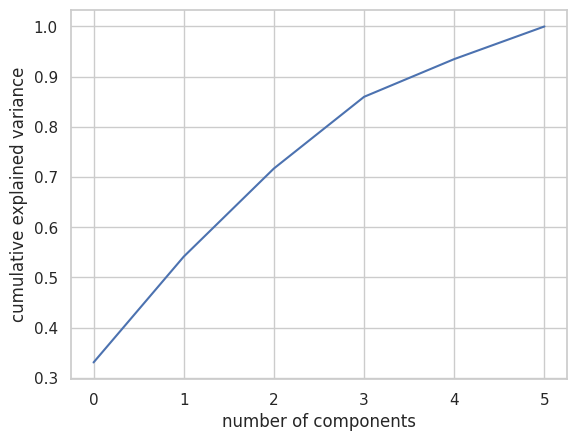

None

,Cumulative Variance Ratio,Explained Variance Ratio
0,0.330494,0.330494
1,0.541325,0.210832
2,0.716991,0.175666
3,0.859807,0.142816
4,0.934997,0.075190
5,1.000000,0.065003


In [ ]:
from sklearn.decomposition import KernelPCA
kpca_score = KernelPCA(kernel='rbf', n_components=6)  # keep only 5 principal components #initializes Kernel PCA with default parameters (RBF kernel)kpca_score = kpca_score.fit_transform(x_standardized_cleaned) #Apply KPCA
kpca_score = kpca_score.fit_transform(x_standardized) #Apply KPCA
explained_variance = np.var(kpca_score, axis=0) #Computes variance of each PC
explained_variance_ratio = explained_variance / np.sum(explained_variance)

#Plot
sns.set(style='whitegrid')
plt.plot(np.cumsum(explained_variance_ratio)) #Determines how many components needed to retain most of the information.
plt.xlabel('number of components')
plt.ylabel('cumulative explained variance')
display(plt.show())

#Display the PC and their variance contribution
evr = explained_variance_ratio
cvr = np.cumsum(explained_variance_ratio)

kpca_df = pd.DataFrame()
kpca_df['Cumulative Variance Ratio'] = cvr
kpca_df['Explained Variance Ratio'] = evr
display(kpca_df.head(15))

#KPCA Tunned

In [ ]:
kpca = KernelPCA(n_components=2) #Creates a Kernel PCA instance that will reduce the dataset to 2 principal components.
x_transformed = kpca.fit_transform(x_standardized)

In [ ]:
x_transformed.shape

(16319, 2)

In [ ]:
print(dir(kpca))

['X_fit_', '__annotations__', '__class__', '__delattr__', '__dict__', '__dir__', '__doc__', '__eq__', '__format__', '__ge__', '__getattribute__', '__getstate__', '__gt__', '__hash__', '__init__', '__init_subclass__', '__le__', '__lt__', '__module__', '__ne__', '__new__', '__reduce__', '__reduce_ex__', '__repr__', '__setattr__', '__setstate__', '__sizeof__', '__sklearn_clone__', '__sklearn_tags__', '__str__', '__subclasshook__', '__weakref__', '_build_request_for_signature', '_centerer', '_check_feature_names', '_check_n_features', '_doc_link_module', '_doc_link_template', '_doc_link_url_param_generator', '_fit_inverse_transform', '_fit_transform_in_place', '_get_default_requests', '_get_doc_link', '_get_kernel', '_get_metadata_request', '_get_param_names', '_get_tags', '_more_tags', '_n_features_out', '_parameter_constraints', '_repr_html_', '_repr_html_inner', '_repr_mimebundle_', '_sklearn_auto_wrap_output_keys', '_validate_data', '_validate_params', 'alpha', 'coef0', 'copy_X', 'degr

#Determine Variable Loadings

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import KernelPCA

eigenvectors = kpca.eigenvectors_

# Calculate the loadings
# The loadings are essentially the dot product between original features and eigenvectors.
loadings = np.dot(x_standardized.T, eigenvectors)

# Step 4: Organize the loadings into a dataframe for better readability
loadings_df = pd.DataFrame(loadings, index=df.columns[:-1], columns=[f"PC{i+1}" for i in range(loadings.shape[1])])

# Step 5: Display the loadings
display(loadings_df)

,PC1,PC2
PAH,-0.109727,-0.672388
"1,3-Butadiene",122.078055,-1.142419
O-Xylene,121.452766,-0.696491
Benzene,118.004162,-1.062207
Toluene,122.094502,-1.118219
Styrene,122.446351,-1.402440
p-dichloro,2.907518,124.103429
Chloroform,2.390850,124.117032


#SVC hyperparameter tuning

In [ ]:
from sklearn.svm import SVC #Support Vector Classifier
from sklearn.model_selection import GridSearchCV #a tool that automates the process of trying different parameter combinations to find the best performing model.

# Define the parameter grid
param_grid = [
    {'C': [ 0.1, 1, 10, 100, 1000],
     'gamma': [0.0001, 0.001, 0.01, 0.1, 1],
     'kernel': ['rbf']},
    {'C': [0.1, 1, 10, 100, 1000],
     'kernel': ['linear']},
]

grid = GridSearchCV(SVC(), param_grid, verbose=2)
grid.fit(x_transformed, y)  # Fit on the 2D KernelPCA-transformed data

# Step 3: Visualize the decision boundary on the transformed data
classifier = grid.best_estimator_

# Display the best parameters and the best score
print("Best parameters found:", grid.best_params_)
print("Best cross-validation score:", grid.best_score_)

Fitting 5 folds for each of 30 candidates, totalling 150 fits
[CV] END ....................C=0.1, gamma=0.0001, kernel=rbf; total time=   0.0s
[CV] END ....................C=0.1, gamma=0.0001, kernel=rbf; total time=   0.0s
[CV] END ....................C=0.1, gamma=0.0001, kernel=rbf; total time=   0.0s
[CV] END ....................C=0.1, gamma=0.0001, kernel=rbf; total time=   0.0s
[CV] END ....................C=0.1, gamma=0.0001, kernel=rbf; total time=   0.0s
[CV] END .....................C=0.1, gamma=0.001, kernel=rbf; total time=   0.0s
[CV] END .....................C=0.1, gamma=0.001, kernel=rbf; total time=   0.1s
[CV] END .....................C=0.1, gamma=0.001, kernel=rbf; total time=   0.0s
[CV] END .....................C=0.1, gamma=0.001, kernel=rbf; total time=   0.0s
[CV] END .....................C=0.1, gamma=0.001, kernel=rbf; total time=   0.0s
[CV] END ......................C=0.1, gamma=0.01, kernel=rbf; total time=   0.0s
[CV] END ......................C=0.1, gamma=0.0

In [ ]:
grid.best_params_

{'C': 0.1, 'gamma': 0.0001, 'kernel': 'rbf'}

/tmp/ipython-input-12-1818316910.py:26: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(X_set[y_set == j, 0], X_set[y_set == j, 1],


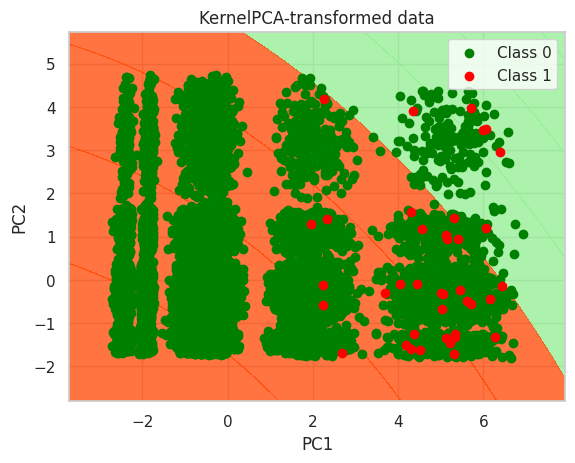

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

# Assume your KernelPCA-transformed data is x_transformed and labels are y
X_set, y_set = x_transformed, y  # Use KernelPCA-transformed features and labels

# Create a meshgrid of points
X1, X2 = np.meshgrid(np.arange(start = X_set[:, 0].min() - 1, stop = X_set[:, 0].max() + 1, step = 0.01),
                     np.arange(start = X_set[:, 1].min() - 1, stop = X_set[:, 1].max() + 1, step = 0.01))

# Flatten the meshgrid to feed it into the classifier's decision function
grid_points = np.array([X1.ravel(), X2.ravel()]).T

# Predict decision function values for each point in the meshgrid
Z = classifier.decision_function(grid_points)

# Reshape the decision function output back to the meshgrid shape
Z = Z.reshape(X1.shape)

# Plot the decision boundary: where decision function equals 0
plt.contourf(X1, X2, Z, alpha=0.75, cmap=ListedColormap(('lightgreen', 'orangered')))

# Plot the data points
for i, j in enumerate(np.unique(y_set)):
    plt.scatter(X_set[y_set == j, 0], X_set[y_set == j, 1],
                c=ListedColormap(('green', 'red'))(i), label=f'Class {j}')

# Add labels and title
plt.title('KernelPCA-transformed data')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.legend()
plt.show()


#Import ICA from sklearn

In [ ]:
from sklearn.decomposition import FastICA

# Apply ICA on KPCA-Transformed Data

In [ ]:
# Define ICA with the same number of components as KPCA
ica = FastICA(n_components=x_transformed.shape[1], random_state=42)

# Apply ICA to the KPCA-transformed data
X_ica = ica.fit_transform(x_transformed)

# Now X_ica is your new feature set for classification

#Determine ICA variable Loadings

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import KernelPCA

ica_components = ica.components_

# Assuming x_standardized has the original feature names as columns
# Use the DataFrame version (from Feature Scaling) instead of the ndarray
loadings_df = pd.DataFrame(ica.components_,
                           index=[f"IC{i+1}" for i in range(ica.components_.shape[0])],
                           columns=[f"PC{i+1}" for i in range(ica.components_.shape[1])])  # Columns should match the KPCA output dimensions


# Step 5: Display the loadings for each component
print(loadings_df)

          PC1       PC2
IC1  2.540371 -4.043777
IC2  3.288456  3.123865


In [ ]:
# Step 2: Calculate correlations between original features and independent components
correlations = np.corrcoef(x_standardized.T, X_ica.T)[:x_standardized.shape[1], x_standardized.shape[1]:]

# Step 3: Convert correlations to a DataFrame for easier interpretation
correlation_df = pd.DataFrame(correlations, index=df.columns[:-1], columns=[f"IC{i+1}" for i in range(X_ica.shape[1])])

# Step 4: Display the correlations to see which original variables load most on the ICs
display(correlation_df)

# Step 5: Optionally, find the variables with the highest correlations with each IC
top_correlations_ic1 = correlation_df["IC1"].abs().sort_values(ascending=False).head(10)
top_correlations_ic2 = correlation_df["IC2"].abs().sort_values(ascending=False).head(10)

print(f"Top variables with highest correlations to IC1:\n{top_correlations_ic1}")
print(f"Top variables with highest correlations to IC2:\n{top_correlations_ic2}")


,IC1,IC2
Individual,0.004550,-0.000364
socioeco.1,0.054660,-0.092086
socioeco.2,-0.053513,0.067910
socioeco.3,0.012265,0.082577
socioeco.4,0.056873,0.159527
race.1,0.493030,-0.594221
race.2,-0.450050,0.610560
Birthplace,-0.005360,-0.003110
Parity,-0.031952,-0.033416
PAH,0.048701,0.118536


Top variables with highest correlations to IC1:
Benzene          0.741665
1,3-Butadiene    0.737905
Styrene          0.732691
Toluene          0.719155
O-Xylene         0.710023
race.1           0.493030
race.2           0.450050
socioeco.4       0.056873
socioeco.1       0.054660
socioeco.2       0.053513
Name: IC1, dtype: float64
Top variables with highest correlations to IC2:
race.2           0.610560
race.1           0.594221
Styrene          0.454549
Toluene          0.443611
O-Xylene         0.437638
Benzene          0.432017
1,3-Butadiene    0.426863
p-dichloro       0.310164
Chloroform       0.308787
socioeco.4       0.159527
Name: IC2, dtype: float64


#Update the GridSearch and Model Training

In [ ]:
grid.fit(X_ica, y)  # Fit on the ICA-transformed data

# Get the best classifier
classifier = grid.best_estimator_

# Display best parameters and score
print("Best parameters found:", grid.best_params_)
print("Best cross-validation score:", grid.best_score_)


Fitting 5 folds for each of 30 candidates, totalling 150 fits
[CV] END ....................C=0.1, gamma=0.0001, kernel=rbf; total time=   0.2s
[CV] END ....................C=0.1, gamma=0.0001, kernel=rbf; total time=   0.1s
[CV] END ....................C=0.1, gamma=0.0001, kernel=rbf; total time=   0.1s
[CV] END ....................C=0.1, gamma=0.0001, kernel=rbf; total time=   0.2s
[CV] END ....................C=0.1, gamma=0.0001, kernel=rbf; total time=   0.1s
[CV] END .....................C=0.1, gamma=0.001, kernel=rbf; total time=   0.1s
[CV] END .....................C=0.1, gamma=0.001, kernel=rbf; total time=   0.1s
[CV] END .....................C=0.1, gamma=0.001, kernel=rbf; total time=   0.1s
[CV] END .....................C=0.1, gamma=0.001, kernel=rbf; total time=   0.1s
[CV] END .....................C=0.1, gamma=0.001, kernel=rbf; total time=   0.1s
[CV] END ......................C=0.1, gamma=0.01, kernel=rbf; total time=   0.1s
[CV] END ......................C=0.1, gamma=0.0

#

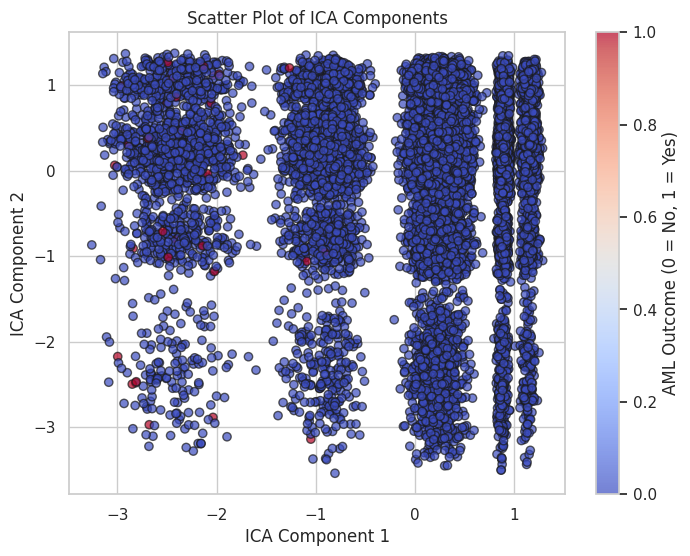

In [ ]:
import matplotlib.pyplot as plt

# Assuming you have applied ICA and obtained X_ica
plt.figure(figsize=(8, 6))
plt.scatter(X_ica[:, 0], X_ica[:, 1], c=y, cmap='coolwarm', edgecolor='k', alpha=0.7)
plt.xlabel("ICA Component 1")
plt.ylabel("ICA Component 2")
plt.title("Scatter Plot of ICA Components")
plt.colorbar(label="AML Outcome (0 = No, 1 = Yes)")
plt.show()